# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
import math # Import math to calculate number of rows and columns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [13]:
df = pd.read_csv('/content/drive/MyDrive/DataSet/bank-additional-full.csv', sep = ';')

In [14]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
# Get the number of rows in top_data
num_rows = df.shape[0]

# Print the number of rows
print(f"Number of rows in df: {num_rows}")

Number of rows in df: 41188


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [16]:
# Convert month to numercal field
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df.loc[:, 'month'] = df['month'].map(month_map)

#Check for unique values
#print("Unique values in 'month' after mapping:")
#print(df['month'].unique())
#print("-" * 30)
#print(df.head())
#print(df['month'].dtype)
#print("-" * 30)


#Convert the 'month' column to float (if needed)
#print("Converting 'month' to float...")
df['month'] = df['month'].astype(int)

# Verify the change after converting to float
#print("\nFinal state of 'month' column:")
#print("Unique values:", df['month'].unique())
#print("Data type:", df['month'].dtype)
#print(df.head())

In [17]:
# Define the mapping from day of the week name to number
day_map = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5
}

df.loc[:, 'day_of_week'] = df['day_of_week'].map(day_map)
df = df.dropna(subset=['day_of_week'])
df['day_of_week'] = df['day_of_week'].astype(int)
#print("Unique values in 'day_of_week' after mapping:")
#print(df['day_of_week'].unique())
#print("-" * 30)
#print(df.head())
#print(df['day_of_week'].dtype) # This should now show a numeric dtype like 'float64'
#print("-" * 30)

# Convert the 'day_of_week' column to integer
# This assumes there are no NaN values in the column after the map and previous cleaning
df['day_of_week'] = df['day_of_week'].astype(int)

# Verify the change after converting to integer
#print("\nFinal state of 'day_of_week' column:")
#print("Unique values:", df['day_of_week'].unique())
#print("Data type:", df['day_of_week'].dtype)
#print(df.head())

In [18]:
# Turn '999' in 'pdays' column to 'no', and rest to a 'yes'.
def talked(x):
  # Check if x is exactly the numeric value 999
  if x == 999:
    return 'no'
  else:
    return 'yes'

# Apply the transformation to the 'pdays' column
# Ensure 'pdays' is numeric before applying the function if there's any doubt,
# though the function will handle numeric input correctly now.
# You might add: df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')
# to handle potential non-numeric values before applying 'talked' if necessary.
df['pdays'] = df['pdays'].apply(talked)

# Rename the column from 'pdays' to 'talked'
df.rename(columns={"pdays":"talked"}, inplace=True)

# Display value counts for the new 'talked' column
print(df['talked'].value_counts())

talked
no     39673
yes     1515
Name: count, dtype: int64


In [19]:
# Turn column 'y' to digit.
def y_content(x):
  # Check if x is exactly the numeric value 999
  if x == 'no':
    return '0'
  else:
    return '1'

# Apply the transformation to the 'pdays' column
# Ensure 'pdays' is numeric before applying the function if there's any doubt,
# though the function will handle numeric input correctly now.
# You might add: df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')
# to handle potential non-numeric values before applying 'talked' if necessary.
df['y'] = df['y'].apply(y_content)

df['y'] = df['y'].astype(int)

In [20]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,talked,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [21]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,int64
day_of_week,int64


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective of this practice is to evaluate the success of a campaign aimed at acquiring new bank account subscribers. This will be achieved by implementing a Data Mining (DM) project based on the CRISP-DM methodology. The project involves developing various models to assess the campaign's success and identify the most effective model. The performance of different classifiers, including k-nearest neighbors, logistic regression, decision trees, and support vector machines, will be directly compared to determine the best approach for this campaign.

In [22]:
# Drop duplicates
df = df.drop_duplicates()
df.shape

(41176, 21)

In [23]:
# Replace the string 'unknown' with NaN across the entire DataFrame
df = df.replace('unknown', np.nan)

# Check the number of NaN values per column after replacement (optional)
print(df.isnull().sum())

age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
talked               0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [24]:
df.shape

(41176, 21)

In [ ]:
# Define the list of columns to check for NaN values
columns_to_check_for_nan = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Drop rows where any of the specified columns have a NaN value
df = df.dropna(subset=columns_to_check_for_nan)

# Verify the change by checking the number of rows and NaN values (optional)
print(f"Shape after dropping rows with NaN in specified columns: {df.shape}")
print("\nNaN counts after dropping:")
print(df[columns_to_check_for_nan].isnull().sum())

Shape after dropping rows with NaN in specified columns: (30478, 21)

NaN counts after dropping:
job          0
marital      0
education    0
default      0
housing      0
loan         0
dtype: int64


In [ ]:
df.shape

(30478, 21)

In [25]:
# Check if the string 'unknown' exists in the 'month' column
contains_unknown_string = (df['month'] == 'unknown').any()

if contains_unknown_string:
    print("The 'month' column contains the string 'unknown'.")
else:
    print("The 'month' column does NOT contain the string 'unknown'.")

# Check for NaN values in the 'month' column
contains_nan = df['month'].isnull().any()

if contains_nan:
    print("The 'month' column contains NaN values.")
else:
    print("The 'month' column does NOT contain NaN values.")

# To get the count of each:
unknown_string_count = (df['month'] == 'unknown').sum()
nan_count = df['month'].isnull().sum()

print(f"\nCount of 'unknown' string in 'month': {unknown_string_count}")
print(f"Count of NaN values in 'month': {nan_count}")

The 'month' column does NOT contain the string 'unknown'.
The 'month' column does NOT contain NaN values.

Count of 'unknown' string in 'month': 0
Count of NaN values in 'month': 0


In [ ]:
df.shape

(30478, 21)

In [26]:
# Check if the string 'unknown' exists in the 'day_of_week' column
contains_unknown_string = (df['day_of_week'] == 'unknown').any()

if contains_unknown_string:
    print("The 'day_of_week' column contains the string 'unknown'.")
else:
    print("The 'day_of_week' column does NOT contain the string 'unknown'.")

# Check for NaN values in the 'month' column
contains_nan = df['day_of_week'].isnull().any()

if contains_nan:
    print("The 'day_of_week' column contains NaN values.")
else:
    print("The 'day_of_week' column does NOT contain NaN values.")

# To get the count of each:
unknown_string_count = (df['day_of_week'] == 'unknown').sum()
nan_count = df['day_of_week'].isnull().sum()

print(f"\nCount of 'unknown' string in 'day_of_week': {unknown_string_count}")
print(f"Count of NaN values in 'day_of_week': {nan_count}")

The 'day_of_week' column does NOT contain the string 'unknown'.
The 'day_of_week' column does NOT contain NaN values.

Count of 'unknown' string in 'day_of_week': 0
Count of NaN values in 'day_of_week': 0


In [27]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,talked,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,NaN,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,5,1,...,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             40846 non-null  object 
 2   marital         41096 non-null  object 
 3   education       39446 non-null  object 
 4   default         32580 non-null  object 
 5   housing         40186 non-null  object 
 6   loan            40186 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  int64  
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  talked          41176 non-null  object 
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [29]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,int64
day_of_week,int64


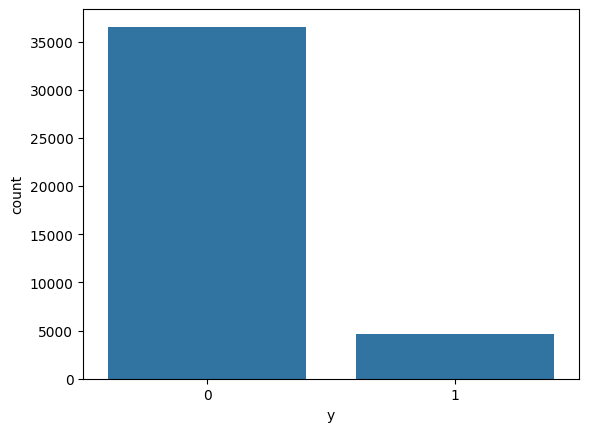

In [30]:
sns.countplot(x='y', data=df)
plt.show()

In [31]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'y' from the list if it exists
if 'y' in categorical_columns:
    categorical_features = [col for col in categorical_columns if col != 'y']
else:
    categorical_features = categorical_columns

print(categorical_features)

# Get the number of rows in df after dropping duplicates
num_rows = df.shape[0]

#Print the number of rows
print(f"Number of rows in df: {num_rows}")

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'talked', 'poutcome']
Number of rows in df: 41176


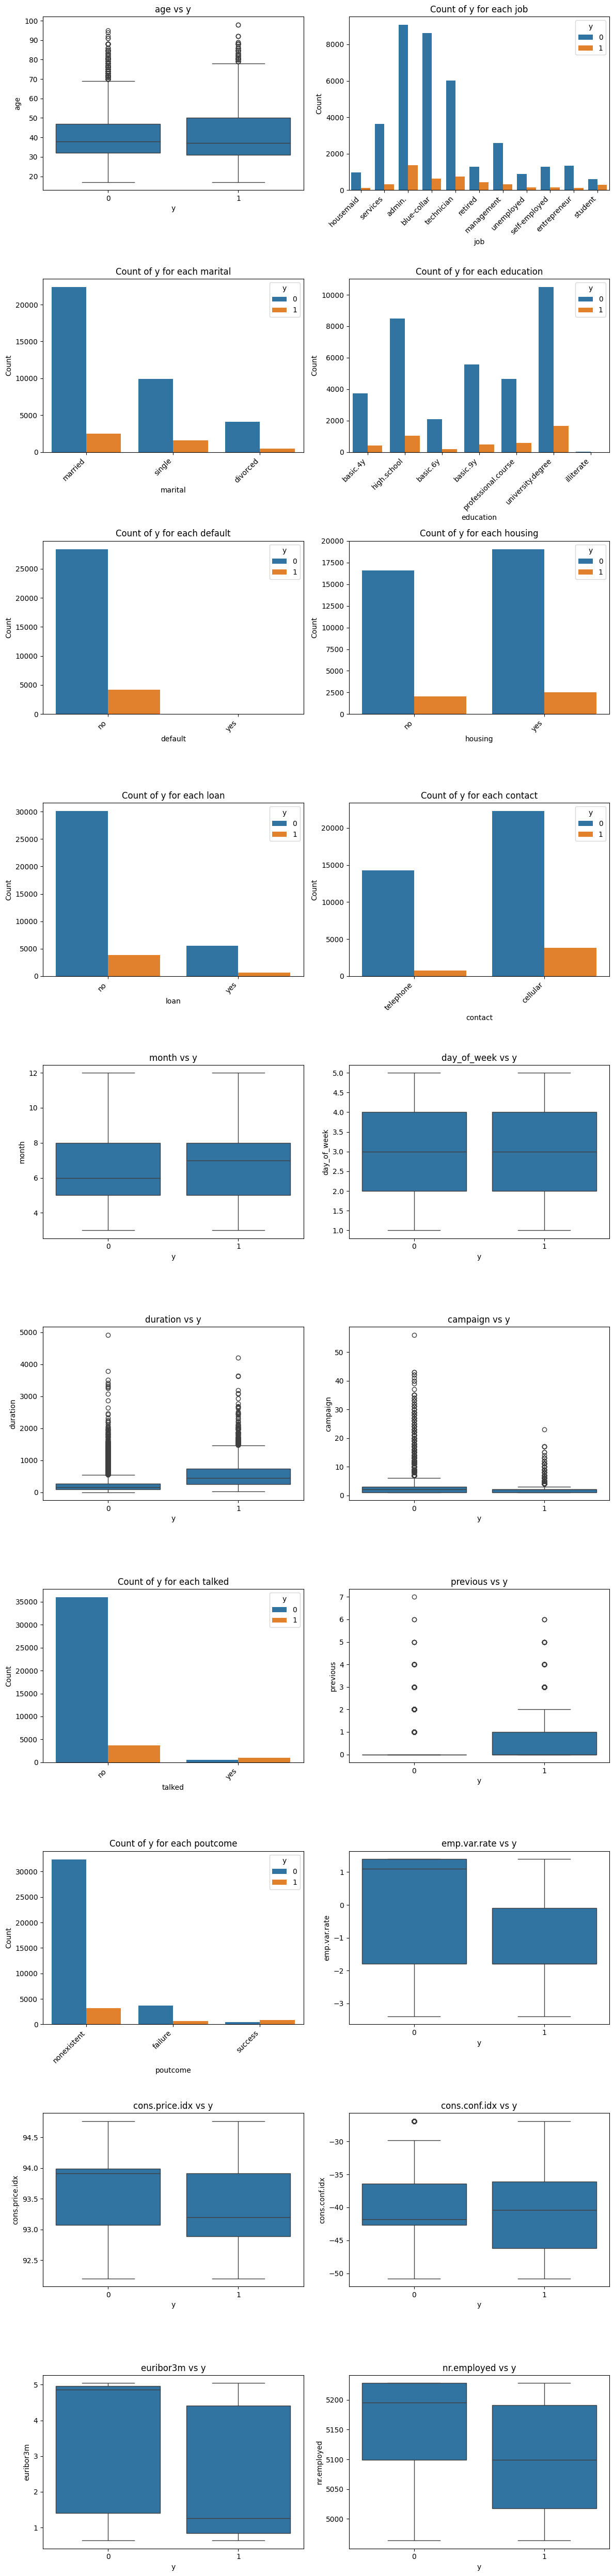

In [33]:
# Plotting all columns against colume 'y'

target_column = 'y'

# Get a list of all columns excluding the target column
feature_columns = [col for col in df.columns if col != target_column]

# Determine the number of plots

plot_columns = []
for col in feature_columns:
    if pd.api.types.is_numeric_dtype(df[col]) or \
       (pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]) and df[target_column].nunique() == 2):
        plot_columns.append(col)

num_plots = len(plot_columns)

# Define the number of columns you want in your subplot grid
n_cols = 2 # For example, 2 plots per row
# Calculate the number of rows needed
n_rows = math.ceil(num_plots / n_cols)

# Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5)) # Adjust figsize as needed (width, height)

# Flatten the axes array if there's more than one row/column for easier iteration
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    # If only one subplot, axes is not an array, so put it in a list for iteration
    axes = [axes]

# Ensure we don't try to plot on non-existent axes if num_plots is less than n_rows * n_cols
# Turn off unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])


# Iterate through each feature column and plot on a subplot
for i, col in enumerate(plot_columns):
    ax = axes[i] # Get the current axis to plot on

    # Check the data type of the current feature column
    if pd.api.types.is_numeric_dtype(df[col]):
        # If the feature is numeric and the target is binary, a box plot is suitable
        # Assuming target is binary based on previous checks
        sns.boxplot(x=target_column, y=col, data=df, ax=ax)
        ax.set_title(f'{col} vs {target_column}')
        ax.set_xlabel(target_column)
        ax.set_ylabel(col)
#        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center') # Use 90 for vertical, 'center' alignment

    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        # If the feature is categorical and the target is binary, a count plot is useful
        sns.countplot(x=col, hue=target_column, data=df, ax=ax)
        ax.set_title(f'Count of {target_column} for each {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

        # Get the current tick locations
        tick_locations = ax.get_xticks()
        # Get the current tick labels
        tick_labels = ax.get_xticklabels()

        # Now set the tick locations AND labels together, or set labels for the existing ticks
        ax.set_xticks(tick_locations)
        ax.set_xticklabels([label.get_text() for label in tick_labels], rotation=45, ha='right')

# Adjust layout to prevent titles/labels overlapping
plt.tight_layout()
plt.show()

In [34]:
# Based on the graphs, droping the following columns:
columns_to_drop = ['default', 'housing', 'loan']

# Drop the specified columns from the DataFrame
# axis=1 indicates that you are dropping columns
# inplace=True modifies the DataFrame directly without needing to reassign it
df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Verify that the columns have been dropped by checking the DataFrame's columns
print("Columns remaining in the DataFrame after dropping:")
print(df.columns)

Columns remaining in the DataFrame after dropping:
Index(['age', 'job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'duration', 'campaign', 'talked', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y'],
      dtype='object')


In [35]:
df.head()

,age,job,marital,education,contact,month,day_of_week,duration,campaign,talked,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,telephone,5,1,261,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,telephone,5,1,149,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,telephone,5,1,226,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,telephone,5,1,151,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,telephone,5,1,307,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [36]:
#This code will helps to select further columns to drop. Generally looking for, column with small standard deviation, its all values are the same (min = max), outliers, or large number of missing values.
df.describe()

,age,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,6.607733,2.979600,258.315815,2.567879,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.112663
std,10.42068,2.041013,1.411539,259.305321,2.770318,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.316184
min,17.00000,3.000000,1.000000,0.000000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,5.000000,2.000000,102.000000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,6.000000,3.000000,180.000000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,8.000000,4.000000,319.000000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,12.000000,5.000000,4918.000000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [37]:
df.isnull().sum()

,0
age,0
job,330
marital,80
education,1730
contact,0
month,0
day_of_week,0
duration,0
campaign,0
talked,0


In [38]:
# Count the occurrences of each unique value in the 'y' column
y_counts = df['y'].value_counts()

# Print the counts
print("Counts of 0s and 1s in column 'y':")
print(y_counts)

Counts of 0s and 1s in column 'y':
y
0    36537
1     4639
Name: count, dtype: int64


In [39]:
df.head()

,age,job,marital,education,contact,month,day_of_week,duration,campaign,talked,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,telephone,5,1,261,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,telephone,5,1,149,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,telephone,5,1,226,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,telephone,5,1,151,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,telephone,5,1,307,1,no,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [40]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_columns)

['job', 'marital', 'education', 'contact', 'talked', 'poutcome']


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [41]:
# Elements to build the Basic Model: Identify the features (X) and the target (y)
X = df.drop('y', axis=1) # 'y' is your target column
y = df['y']

# Dropped columns, these are the relevant ones
bank_info_features = ['age', 'job', 'marital', 'education']

# Select only these bank information features from X for this step
X_bank_info = X[bank_info_features]

# Identify which of these bank information features are categorical
categorical_bank_info_cols = X_bank_info.select_dtypes(include='object').columns.tolist()

# Perform one-hot encoding on the categorical bank information features
# The 'dummy_na=False' ensures we don't create a column for NaN values if any somehow remained
X_bank_info_encoded = pd.get_dummies(X_bank_info, columns=categorical_bank_info_cols, dummy_na=False)

# Display the first few rows of the encoded features
print("Original bank info features:")
print(X_bank_info.head())
print("\nEncoded bank info features:")
print(X_bank_info_encoded.head())

# Display the shape to see how many columns were created by one-hot encoding
print(f"\nShape of original bank info features: {X_bank_info.shape}")
print(f"Shape of encoded bank info features: {X_bank_info_encoded.shape}")

# The target variable y is already prepared (0s and 1s) based on your previous steps
print("\nTarget variable 'y' (first 5 values):")
print(y.head())

Original bank info features:
   age        job  marital    education
0   56  housemaid  married     basic.4y
1   57   services  married  high.school
2   37   services  married  high.school
3   40     admin.  married     basic.6y
4   56   services  married  high.school

Encoded bank info features:
   age  job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
0   56       False            False             False           True   
1   57       False            False             False          False   
2   37       False            False             False          False   
3   40        True            False             False          False   
4   56       False            False             False          False   

   job_management  job_retired  job_self-employed  job_services  job_student  \
0           False        False              False         False        False   
1           False        False              False          True        False   
2           False        Fals

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [42]:
X = df.drop('y', axis=1) # 'y' is your target column
y = df['y']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [45]:
# Create a baseline model using DummyClassifier
# 'most_frequent' strategy predicts the class label that appears most often in the training set.
baseline_model = DummyClassifier(strategy="most_frequent")

# The dummy model only needs y_train to determine the most frequent class
baseline_model.fit(X_train, y_train)

# Evaluate the baseline model's accuracy on the test set
baseline_accuracy = baseline_model.score(X_test, y_test)

# Print the baseline accuracy
print(f"Baseline Model Accuracy (Most Frequent Class): {baseline_accuracy:.4f}")

# You can also manually calculate the accuracy by finding the proportion of the most frequent class in y_test
most_frequent_class = y_train.mode()[0]
manual_baseline_accuracy = (y_test == most_frequent_class).mean()
print(f"Manual Baseline Accuracy (Most Frequent Class in Test Set): {manual_baseline_accuracy:.4f}")



Baseline Model Accuracy (Most Frequent Class): 0.8859
Manual Baseline Accuracy (Most Frequent Class in Test Set): 0.8859


In [46]:
# Make predictions
y_pred = baseline_model.predict(X_test)

# Evaluate the baseline model
mse = mean_squared_error(y_test, y_pred)
print(f"Baseline Model Mean Squared Error: {mse:.2f}")

Baseline Model Mean Squared Error: 0.11


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [47]:
# Identify categorical columns in X_train
categorical_cols = X_train.select_dtypes(include='object').columns

# Perform one-hot encoding on the training and testing data
# Use get_dummies and handle unknown categories in the test set by ignoring them
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

In [48]:
# Align columns - this is important to ensure both train and test sets have the same columns
# in case one-hot encoding results in different columns (e.g., if a category is only in train)
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols] # Ensure the order of columns is the same


In [49]:
# Create an instance of the Logistic Regression model and fit it
model = LogisticRegression(max_iter=1000)
model.fit(X_train_encoded, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [52]:
# Score the model on the test data
accuracy = model.score(X_test_encoded, y_test)

# Print the accuracy
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.9089319539559959


### Problem 9: Score the Model

What is the accuracy of your model?

In [50]:
# Score the model on the test data
accuracy = model.score(X_test_encoded, y_test)

# Print the accuracy
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.9089319539559959


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
| KNN|  |0.310       |0.9285          |0.9003
Decision Tree   0.1935        1.000       0.8876
SVM           13.4378       0.9206      0.9065

In [53]:
# Record the start time for training
start_time = time.time()

# Create an instance of the KNN classifier with default parameters (n_neighbors=5)
knn_model = KNeighborsClassifier()

# Train the KNN model
knn_model.fit(X_train_encoded, y_train)

# Record the end time for training and calculate the training time
train_time_knn = time.time() - start_time

# Create an instance of the KNN classifier with default parameters (n_neighbors=5)
knn_model = KNeighborsClassifier()

# Train the KNN model
knn_model.fit(X_train_encoded, y_train)

# Record the end time for training and calculate the training time
train_time_knn = time.time() - start_time

# Score the KNN model on the training data
train_accuracy_knn = knn_model.score(X_train_encoded, y_train)

# Score the KNN model on the test data
test_accuracy_knn = knn_model.score(X_test_encoded, y_test)

# Print the results
print(f"KNN Model:")
print(f"  Train Time: {train_time_knn:.4f} seconds")
print(f"  Train Accuracy: {train_accuracy_knn:.4f}")
print(f"  Test Accuracy: {test_accuracy_knn:.4f}")


KNN Model:
  Train Time: 0.0310 seconds
  Train Accuracy: 0.9285
  Test Accuracy: 0.9003


In [54]:
# Record the start time for training
start_time = time.time()

# Create an instance of the Decision Tree classifier with default parameters
dt_model = DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility

# Train the Decision Tree model
dt_model.fit(X_train_encoded, y_train)

# Record the end time for training and calculate the training time
train_time_dt = time.time() - start_time

# Score the Decision Tree model on the training data
train_accuracy_dt = dt_model.score(X_train_encoded, y_train)

# Score the Decision Tree model on the test data
test_accuracy_dt = dt_model.score(X_test_encoded, y_test)

# Print the results
print(f"Decision Tree Model:")
print(f"  Train Time: {train_time_dt:.4f} seconds")
print(f"  Train Accuracy: {train_accuracy_dt:.4f}")
print(f"  Test Accuracy: {test_accuracy_dt:.4f}")

Decision Tree Model:
  Train Time: 0.1935 seconds
  Train Accuracy: 1.0000
  Test Accuracy: 0.8876


In [55]:
# Record the start time for training
start_time = time.time()

# Create a pipeline that first scales the data, then fits the SVM model

svm_model = make_pipeline(StandardScaler(), SVC())

# Train the SVM model using the pipeline

svm_model.fit(X_train_encoded, y_train)

# Record the end time for training and calculate the training time
train_time_svm = time.time() - start_time

# Score the SVM model on the training data

train_accuracy_svm = svm_model.score(X_train_encoded, y_train)

# Score the SVM model on the test data

test_accuracy_svm = svm_model.score(X_test_encoded, y_test)

# Print the results
print(f"SVM Model:")
print(f"  Train Time: {train_time_svm:.4f} seconds")
print(f"  Train Accuracy: {train_accuracy_svm:.4f}")
print(f"  Test Accuracy: {test_accuracy_svm:.4f}")

SVM Model:
  Train Time: 13.4378 seconds
  Train Accuracy: 0.9206
  Test Accuracy: 0.9065


Using decision_function for SVM ROC plot.


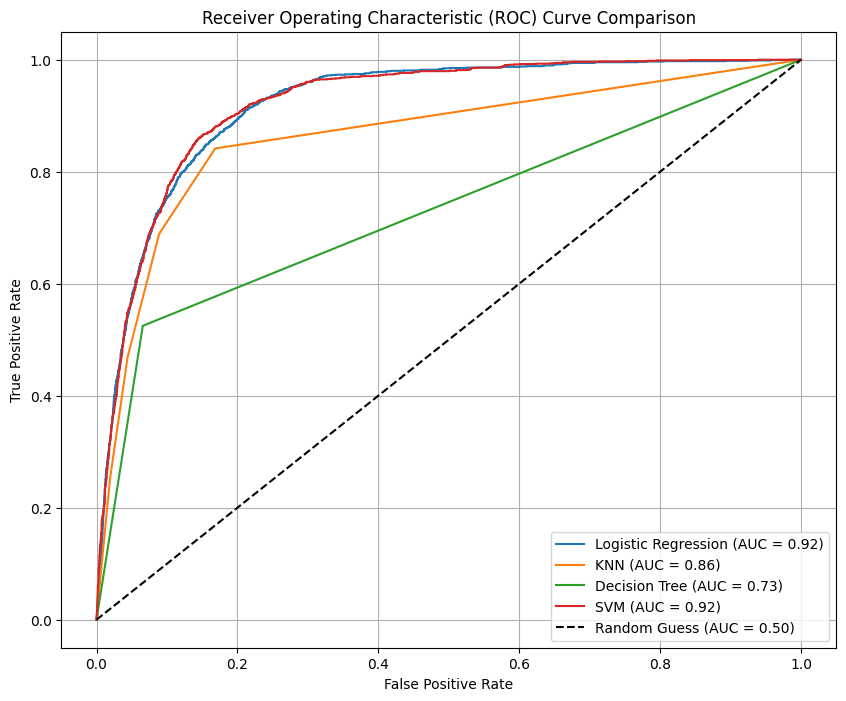

In [57]:
# Dictionary to store model names and their corresponding models
models = {
    "Logistic Regression": model,  # Logistic Regression model
    "KNN": knn_model,              # KNN model
    "Decision Tree": dt_model,     # Decision Tree model
    "SVM": svm_model               # SVM pipeline
}

plt.figure(figsize=(10, 8))

# Iterate through each model, calculate ROC metrics, and plot the curve
for name, trained_model in models.items():
    if hasattr(trained_model, "predict_proba"):
        y_pred_proba = trained_model.predict_proba(X_test_encoded)[:, 1] # Get probability of the positive class

        # Calculate the ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) # Use y_test directly if it's 0/1 binary

        # Calculate the AUC
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        # Plot the ROC curve
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    elif hasattr(trained_model, "decision_function"):
         print(f"Using decision_function for {name} ROC plot.")
         y_pred_proba = trained_model.decision_function(X_test_encoded)

         # Calculate the ROC curve
         fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

         # Calculate the AUC
         roc_auc = roc_auc_score(y_test, y_pred_proba)

         # Plot the ROC curve
         plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    else:
        print(f"Skipping ROC plot for {name} as it does not support predict_proba or decision_function.")
        continue # Skip to the next model


# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Add plot title and labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
# Save the figure
plt.savefig('roc_curve_comparison.png')
plt.show()

Problem 11: Improving the Model
Now that we have some basic models on the board, we want to try to improve these. Below, we list a few things to explore in this pursuit.

More feature engineering and exploration. For example, should we keep the gender feature? Why or why not?
Hyperparameter tuning and grid search. All of our models have additional hyperparameters to tune and explore. For example the number of neighbors in KNN or the maximum depth of a Decision Tree.
Adjust your performance metric

Starting probability collection for Lift curve...

Processing model: Logistic Regression
Does it have predict_proba? True
Attempting predict_proba for Logistic Regression...
predict_proba successful for Logistic Regression. Shape: (13726,)
Added Logistic Regression probabilities to dictionary.

Processing model: KNN
Does it have predict_proba? True
Attempting predict_proba for KNN...
predict_proba successful for KNN. Shape: (13726,)
Added KNN probabilities to dictionary.

Processing model: Decision Tree
Does it have predict_proba? True
Attempting predict_proba for Decision Tree...
predict_proba successful for Decision Tree. Shape: (13726,)
Added Decision Tree probabilities to dictionary.

Processing model: SVM
Does it have predict_proba? False
Skipping Lift plot for SVM as it does not support predict_proba.

Finished probability collection.
Models successfully added to model_probabilities: ['Logistic Regression', 'KNN', 'Decision Tree']

Starting Lift data calculation and plotting...
C

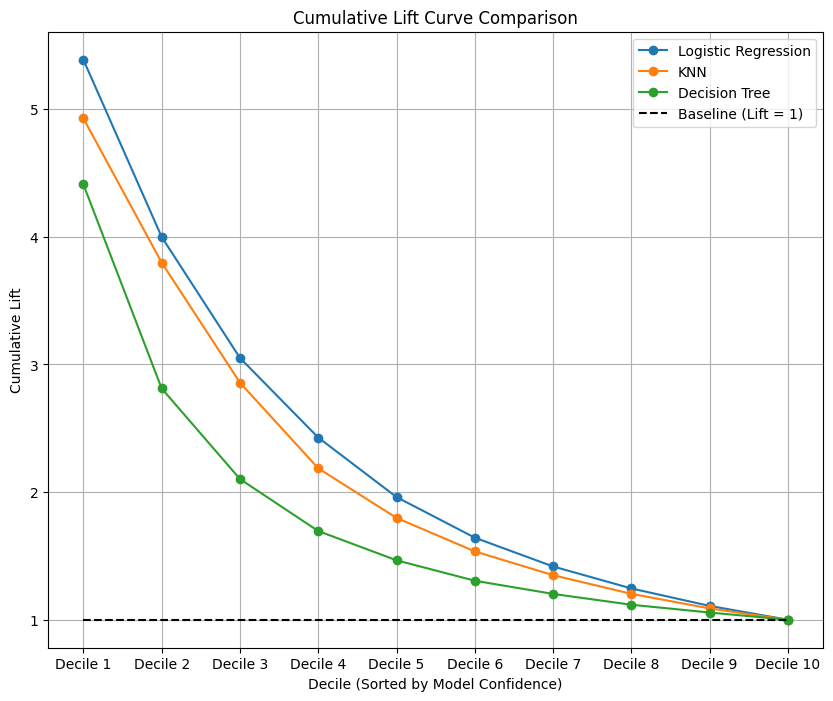


Lift Table for Logistic Regression:
      Decile  Response Rate  Cumulative Response Rate      Lift  \
0   Decile 1       0.614712                  0.614712  5.387957   
1   Decile 2       0.297888                  0.456300  2.610989   
2   Decile 3       0.131828                  0.348143  1.155474   
3   Decile 4       0.063365                  0.276948  0.555394   
4   Decile 5       0.010925                  0.223744  0.095758   
5   Decile 6       0.005827                  0.187424  0.051071   
6   Decile 7       0.007289                  0.161707  0.063885   
7   Decile 8       0.004373                  0.142051  0.038331   
8   Decile 9       0.001458                  0.126437  0.012777   
9  Decile 10       0.002915                  0.114090  0.025554   

   Cumulative Lift  
0         5.387957  
1         3.999473  
2         3.051473  
3         2.427454  
4         1.961114  
5         1.642774  
6         1.417359  
7         1.245075  
8         1.108219  
9         1.000

In [60]:
# Using Comulative Lift Copmareison Method

# Lift Plotting
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Using Comulative Lift Copmareison Method
y_test_binary = y_test # y_test is already 0s and 1s

# Dictionary to store model names and their corresponding predicted probabilities
model_probabilities = {}

# Get predicted probabilities for each model
models = {
    "Logistic Regression": model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "SVM": svm_model # This SVM should now have probability=True
}

print("Starting probability collection for Lift curve...")
# Iterate through each model, calculate ROC metrics, and plot the curve
for name, trained_model in models.items():
    print(f"\nProcessing model: {name}")
    print(f"Does it have predict_proba? {hasattr(trained_model, 'predict_proba')}")

    # Check if the model has the predict_proba method
    if hasattr(trained_model, "predict_proba"):
        try:
            print(f"Attempting predict_proba for {name}...")
            # Get probability of the positive class
            y_pred_proba = trained_model.predict_proba(X_test_encoded)[:, 1]
            print(f"predict_proba successful for {name}. Shape: {y_pred_proba.shape}")

            # Check if the shape of probabilities matches y_test
            if y_pred_proba.shape[0] != y_test_binary.shape[0]:
                print(f"Shape mismatch for {name}: y_pred_proba shape {y_pred_proba.shape[0]}, y_test shape {y_test_binary.shape[0]}. Skipping.")
                continue

            model_probabilities[name] = y_pred_proba
            print(f"Added {name} probabilities to dictionary.")

        except Exception as e:
            print(f"An error occurred during predict_proba for {name}: {e}")
            # If predict_proba fails for some reason, skip this model
            continue
    else:
        print(f"Skipping Lift plot for {name} as it does not support predict_proba.")
        continue # Skip to the next model

print("\nFinished probability collection.")
print(f"Models successfully added to model_probabilities: {list(model_probabilities.keys())}")


# Function to calculate Lift
def calculate_lift(y_true, y_scores, num_buckets=10):
    # Create a DataFrame
    data = pd.DataFrame({'true': y_true, 'score': y_scores})

    # Handle potential division by zero if no positive examples in y_true
    total_response_rate = data['true'].mean()
    if total_response_rate == 0:
        print("Warning: No positive examples in y_true. Lift cannot be calculated.")
        return pd.DataFrame() # Return empty DataFrame

    # Sort by score in descending order
    data = data.sort_values(by='score', ascending=False).reset_index(drop=True)

    # Calculate bucket size
    total_rows = len(data)
    if total_rows == 0:
        print("Warning: No data to calculate Lift.")
        return pd.DataFrame() # Return empty DataFrame

    bucket_size = total_rows // num_buckets
    if total_rows % num_buckets != 0:
        remainder = total_rows % num_buckets
        bucket_sizes = [bucket_size + 1] * remainder + [bucket_size] * (num_buckets - remainder)
    else:
        bucket_sizes = [bucket_size] * num_buckets

    # Initialize lists to store results
    buckets = []
    response_rates = []
    cumulative_response_rates = []
    lifts = []
    cumulative_lifts = []


    current_index = 0
    cumulative_true = 0
    cumulative_total = 0

    for i in range(num_buckets):
        # Ensure bucket size does not exceed remaining data
        current_bucket_size = min(bucket_sizes[i], total_rows - current_index)
        if current_bucket_size <= 0:
             break # Stop if no data left

        bucket_data = data.iloc[current_index : current_index + current_bucket_size]
        num_true_in_bucket = bucket_data['true'].sum()
        num_total_in_bucket = len(bucket_data)

        cumulative_true += num_true_in_bucket
        cumulative_total += num_total_in_bucket

        # Calculate response rate for the current bucket
        response_rate_bucket = num_true_in_bucket / num_total_in_bucket if num_total_in_bucket > 0 else 0
        response_rates.append(response_rate_bucket)

        # Calculate cumulative response rate up to the current bucket
        cumulative_response_rate_bucket = cumulative_true / cumulative_total if cumulative_total > 0 else 0
        cumulative_response_rates.append(cumulative_response_rate_bucket)

        # Calculate lift for the current bucket
        lift_bucket = response_rate_bucket / total_response_rate if total_response_rate > 0 else 0
        lifts.append(lift_bucket)

        # Calculate cumulative lift up to the current bucket
        cumulative_lift_bucket = cumulative_response_rate_bucket / total_response_rate if total_response_rate > 0 else 0
        cumulative_lifts.append(cumulative_lift_bucket)

        buckets.append(f'Decile {i+1}')
        current_index += current_bucket_size # Use current_bucket_size for index update

    # Create a DataFrame from the results
    lift_df = pd.DataFrame({
        'Decile': buckets,
        'Response Rate': response_rates,
        'Cumulative Response Rate': cumulative_response_rates,
        'Lift': lifts,
        'Cumulative Lift': cumulative_lifts
    })

    return lift_df


print("\nStarting Lift data calculation and plotting...")
# Calculate and store Lift data for each model
lift_data = {}
for name, probas in model_probabilities.items():
    print(f"Calculating Lift for {name}...")
    try:
        lift_df = calculate_lift(y_test_binary, probas, num_buckets=10)
        if not lift_df.empty:
             lift_data[name] = lift_df
             print(f"Lift data calculated for {name}.")
        else:
             print(f"Lift data calculation returned empty DataFrame for {name}. Skipping.")
    except Exception as e:
        print(f"An error occurred during Lift calculation for {name}: {e}")
        continue

print("\nFinished Lift data calculation.")
print(f"Models available for plotting: {list(lift_data.keys())}")

# Plotting the Cumulative Lift Curve
plt.figure(figsize=(10, 8))

# Check if lift_data is empty before plotting
if not lift_data:
    print("No models had successful Lift data calculation to plot.")
else:
    for name, lift_df in lift_data.items():
        plt.plot(lift_df['Decile'], lift_df['Cumulative Lift'], marker='o', linestyle='-', label=name)

    # Plot the baseline (random targeting) lift curve
    # Use the deciles from any model's lift_df since they should be the same
    plt.plot(lift_data[list(lift_data.keys())[0]]['Decile'], [1] * len(lift_data[list(lift_data.keys())[0]]), 'k--', label='Baseline (Lift = 1)')

    plt.xlabel('Decile (Sorted by Model Confidence)')
    plt.ylabel('Cumulative Lift')
    plt.title('Cumulative Lift Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.savefig('Comulative Lift Copmareison.png')
    plt.show()
# Print the Lift tables for each model
for name, lift_df in lift_data.items():
    print(f"\nLift Table for {name}:")
    print(lift_df)

# **MODEL TUNNING**

In [61]:
# Define parameter grid for Logistic Regression
# Using cv=3 for faster initial tuning
cv_value = 3

# Define a slightly smaller parameter grid for Logistic Regression
# Reduced number of C values for faster tuning
param_grid_lr_smaller = {
    'C': [0.01, 1, 100], # Reduced number of C values
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Create GridSearchCV object with reduced cv and smaller grid
print("Starting GridSearchCV for Logistic Regression...")
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), # Add random_state for reproducibility
    param_grid_lr_smaller,
    cv=cv_value, # Use the specified cv value
    scoring='roc_auc',
    n_jobs=-1
)

# Fit the grid search on your training data
start_time_tune_lr = time.time()
grid_search_lr.fit(X_train_encoded, y_train)
train_time_tune_lr = time.time() - start_time_tune_lr


Starting GridSearchCV for Logistic Regression...


In [62]:
## Get the best parameters found
best_params_lr = grid_search_lr.best_params_
print(f"Best parameters for Logistic Regression: {best_params_lr}")

## Get the best cross-validation score
best_score_lr = grid_search_lr.best_score_
print(f"Best cross-validation AUC score for Logistic Regression: {best_score_lr:.4f}")
print(f"Logistic Regression Tuning Time: {train_time_tune_lr:.4f} seconds")

Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC score for Logistic Regression: 0.9281
Logistic Regression Tuning Time: 830.3015 seconds


In [63]:
## Evaluate the best model on the held-out test set
best_lr_model = grid_search_lr.best_estimator_
test_auc_lr = roc_auc_score(y_test, best_lr_model.predict_proba(X_test_encoded)[:, 1])
print(f"Test set AUC score for tuned Logistic Regression: {test_auc_lr:.4f}")

## Using RandomizedSearchCV for faster tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

## Define a parameter distribution for Logistic Regression using RandomizedSearchCV

param_dist_lr = {
    'C': loguniform(1e-4, 1e2), # Sample C from a log-uniform distribution
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # Note: you might need to handle solver/penalty compatibility
}

Test set AUC score for tuned Logistic Regression: 0.9230


In [64]:
## Create RandomizedSearchCV object
#n_iter is the number of parameter settings that are sampled. Reduce this for speed.

n_iter_search = 50 # Number of parameter combinations to try

print("\nStarting RandomizedSearchCV for Logistic Regression...")
random_search_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist_lr,
    n_iter=n_iter_search,
    cv=cv_value, # Use the specified cv value
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42 # Add random_state for reproducibility of random sampling
)


Starting RandomizedSearchCV for Logistic Regression...


In [65]:
## Fit the random search
start_time_rand_lr = time.time()
random_search_lr.fit(X_train_encoded, y_train)
train_time_rand_lr = time.time() - start_time_rand_lr

print(f"Best parameters (Random Search) for Logistic Regression: {random_search_lr.best_params_}")
print(f"Best cross-validation AUC score (Random Search) for Logistic Regression: {random_search_lr.best_score_:.4f}")
print(f"Logistic Regression Random Search Tuning Time: {train_time_rand_lr:.4f} seconds")

## Evaluate the best model from random search on the test set
best_rand_lr_model = random_search_lr.best_estimator_
test_auc_rand_lr = roc_auc_score(y_test, best_rand_lr_model.predict_proba(X_test_encoded)[:, 1])
print(f"Test set AUC score for tuned Logistic Regression (Random Search): {test_auc_rand_lr:.4f}")

Best parameters (Random Search) for Logistic Regression: {'C': np.float64(0.4418441521199725), 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC score (Random Search) for Logistic Regression: 0.9287
Logistic Regression Random Search Tuning Time: 2372.2431 seconds
Test set AUC score for tuned Logistic Regression (Random Search): 0.9221


In [66]:
# Optimize SVM Training/Tuning ---
# For initial comparison (Problem 10) - FAST SVM
print("\nTraining SVM with default settings (no probability=True) for initial comparison...")
start_time_svm_fast = time.time()
svm_model_fast = make_pipeline(StandardScaler(), SVC(random_state=42))
svm_model_fast.fit(X_train_encoded, y_train)
train_time_svm_fast = time.time() - start_time_svm_fast
test_accuracy_svm_fast = svm_model_fast.score(X_test_encoded, y_test)
print(f"SVM Model (Fast) Train Time: {train_time_svm_fast:.4f} seconds")
print(f"SVM Model (Fast) Test Accuracy: {test_accuracy_svm_fast:.4f}")


Training SVM with default settings (no probability=True) for initial comparison...
SVM Model (Fast) Train Time: 29.0985 seconds
SVM Model (Fast) Test Accuracy: 0.9065


In [67]:
# Need probabilities for Lift or AUC (if AUC using predict_proba) - SLOWER SVM
print("\nTraining SVM with probability=True for Lift/AUC plotting...")
start_time_svm_proba = time.time()

svm_model = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))
svm_model.fit(X_train_encoded, y_train)
train_time_svm_proba = time.time() - start_time_svm_proba
print(f"SVM Model (with probability=True) Train Time: {train_time_svm_proba:.4f} seconds")


Training SVM with probability=True for Lift/AUC plotting...
SVM Model (with probability=True) Train Time: 138.0352 seconds


In [68]:
## Tuning SVM (potentially very slow)
print("\nStarting SVM Tuning (might take a while)...")
param_grid_svm = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
    'svc__kernel': ['rbf']
}


Starting SVM Tuning (might take a while)...


In [69]:
grid_search_svm = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(random_state=42)), # Tune without probability=True for speed
    param_grid_svm,
    cv=cv_value,
    scoring='roc_auc',
    n_jobs=-1
)

start_time_tune_svm = time.time()
grid_search_svm.fit(X_train_encoded, y_train)
train_time_tune_svm = time.time() - start_time_tune_svm

print(f"Best parameters for SVM: {grid_search_svm.best_params_}")
print(f"Best cross-validation AUC score for SVM: {grid_search_svm.best_score_:.4f}")
print(f"SVM Tuning Time: {train_time_tune_svm:.4f} seconds")

best_svm_model = grid_search_svm.best_estimator_
#Evaluate tuned SVM
test_auc_svm = roc_auc_score(y_test, best_svm_model.decision_function(X_test_encoded))
print(f"Test set AUC score for tuned SVM: {test_auc_svm:.4f}")

Best parameters for SVM: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best cross-validation AUC score for SVM: 0.9241
SVM Tuning Time: 189.6786 seconds
Test set AUC score for tuned SVM: 0.9226


In [ ]:
## Apply similar tuning strategies to KNN and Decision Tree
print("\nStarting KNN Tuning...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9], # Fewer neighbors for faster tuning
    'weights': ['uniform', 'distance']
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=cv_value,
    scoring='roc_auc',
    n_jobs=-1
)
start_time_tune_knn = time.time()
grid_search_knn.fit(X_train_encoded, y_train)
train_time_tune_knn = time.time() - start_time_tune_knn

print(f"Best parameters for KNN: {grid_search_knn.best_params_}")
print(f"Best cross-validation AUC score for KNN: {grid_search_knn.best_score_:.4f}")
print(f"KNN Tuning Time: {train_time_tune_knn:.4f} seconds")

best_knn_model = grid_search_knn.best_estimator_
test_auc_knn = roc_auc_score(y_test, best_knn_model.predict_proba(X_test_encoded)[:, 1])
print(f"Test set AUC score for tuned KNN: {test_auc_knn:.4f}")


Starting KNN Tuning...
Best parameters for KNN: {'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation AUC score for KNN: 0.8915
KNN Tuning Time: 17.9493 seconds
Test set AUC score for tuned KNN: 0.8871


In [ ]:
## Decision Tree tuning
print("\nStarting Decision Tree Tuning...")
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # Limited depth options
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv_value,
    scoring='roc_auc',
    n_jobs=-1
)

start_time_tune_dt = time.time()
grid_search_dt.fit(X_train_encoded, y_train)
train_time_tune_dt = time.time() - start_time_tune_dt

print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best cross-validation AUC score for Decision Tree: {grid_search_dt.best_score_:.4f}")
print(f"Decision Tree Tuning Time: {train_time_tune_dt:.4f} seconds")



Starting Decision Tree Tuning...
Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation AUC score for Decision Tree: 0.9193
Decision Tree Tuning Time: 16.1927 seconds


In [ ]:
best_dt_model = grid_search_dt.best_estimator_
test_auc_dt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test_encoded)[:, 1])
print(f"Test set AUC score for tuned Decision Tree: {test_auc_dt:.4f}")

Test set AUC score for tuned Decision Tree: 0.9125


##### Questions